# Adım 6–7 — RadioML 2016 vs 2018 (karşılaştırma + EDA raporu)

Akış şemasındaki **mor kutular**: iki veri kümesi `01` ve `02` defterlerinde ayrı incelendikten sonra burada **özet tablo**, **ortak modülasyonlara yaklaşık eşleme**, **görsel karşılaştırma** ve **rapor taslağı** üretilir.

**Girdiler**
- `../results/results_2016/` — `01_eda_2016.ipynb` çıktıları
- `../results/results_2018/` — `02_eda_2018.ipynb` çıktıları
- İsteğe bağlı ham dosyalar: 2016 pickle (SNR uçları), 2018 HDF5 (SNR uçları)

**Çıktılar**
- `../results/results_compare/` — özet CSV (isteğe bağlı kayıt)

**Önemli:** 2016 ve 2018 I/Q **ölçekleri** farklıdır (ör. 2016’da tipik `I_std` ~0,006, 2018’de ~0,7). Ortak mod tablosu **gözle karşılaştırma** içindir; mutlak sayıları aynı fiziksel birim sanmayın.


In [1]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

R16 = ROOT / "results" / "results_2016"
R18 = ROOT / "results" / "results_2018"
OUT = ROOT / "results" / "results_compare"
OUT.mkdir(parents=True, exist_ok=True)

PKL_2016 = ROOT / "data" / "raw" / "radioml_2016" / "RML2016.10a_dict.pkl"
H5_2018 = ROOT / "data" / "raw" / "radioml_2018" / "GOLD_XYZ_OSC.0001_1024.hdf5"

plt.rcParams["figure.dpi"] = 100
print("ROOT:", ROOT)
print("OUT:", OUT)


ROOT: /Users/silaozyilmaz/YZG_Proje/amc-modulation-classification
OUT: /Users/silaozyilmaz/YZG_Proje/amc-modulation-classification/results/results_compare


In [2]:
s16 = pd.read_csv(R16 / "eda_2016_stats_by_class.csv")
s18 = pd.read_csv(R18 / "eda_2018_stats_by_class.csv")

if "n_scalar" in s18.columns:
    s18 = s18.copy()
    s18["n_rows"] = (s18["n_scalar"] // 1024).astype(np.int64)
else:
    s18["n_rows"] = s18.get("n", 0)

print("2016 sınıf:", len(s16), "toplam örnek:", int(s16["n"].sum()))
print("2018 sınıf:", len(s18), "toplam örnek:", int(s18["n_rows"].sum()))
print("\n2016 ilk satırlar:")
print(s16.head(3).to_string(index=False))
print("\n2018 ilk satırlar:")
print(s18.head(3).to_string(index=False))


2016 sınıf: 11 toplam örnek: 220000
2018 sınıf: 24 toplam örnek: 2555904

2016 ilk satırlar:
modulation     n    I_mean    I_std     I_min    I_max    Q_mean    Q_std     Q_min    Q_max
      8PSK 20000 -0.000091 0.006003 -0.073416 0.097091 -0.000027 0.006033 -0.154946 0.055247
    AM-DSB 20000  0.001086 0.005195 -0.027984 0.030807 -0.003390 0.005489 -0.028658 0.027423
    AM-SSB 20000 -0.000161 0.006221 -0.029821 0.030667 -0.000041 0.006282 -0.028998 0.027936

2018 ilk satırlar:
modulation  n_scalar    I_mean    I_std     I_min    I_max    Q_mean    Q_std     Q_min    Q_max  n_rows
   128APSK 109051904  0.000035 0.708131 -4.006309 3.774262  0.000121 0.708205 -3.857535 3.886802  106496
    128QAM 109051904  0.000096 0.708169 -3.756103 4.135806 -0.000128 0.708167 -3.795928 3.775487  106496
    16APSK 109051904 -0.000136 0.708125 -3.943531 3.903133  0.000175 0.708199 -3.632038 3.983972  106496


## Adım 6 — Veri kümesi özeti (otomatik tablo)


In [3]:
def file_mb(p: Path) -> str:
    if not p.is_file():
        return "— (dosya yok)"
    return f"{p.stat().st_size / (1024 ** 2):.1f} MB"


n16, c16 = int(s16["n"].sum()), len(s16)
n18, c18 = int(s18["n_rows"].sum()), len(s18)
per16 = s16["n"].min(), s16["n"].max()
per18 = int(s18["n_rows"].min()), int(s18["n_rows"].max())

snr_16_txt = "—"
if PKL_2016.is_file():
    with open(PKL_2016, "rb") as f:
        d16 = pickle.load(f, encoding="latin1")
    zs = [k[1] for k in d16.keys()]
    snr_16_txt = f"{min(zs)} … {max(zs)} dB (pickle anahtarları)"

snr_18_txt = "—"
if H5_2018.is_file():
    from src.data.radioml2018 import iter_label_snr_chunks

    z_lo = z_hi = None
    for _, z in iter_label_snr_chunks(H5_2018, chunk_rows=65536):
        lo, hi = int(z.min()), int(z.max())
        z_lo = lo if z_lo is None else min(z_lo, lo)
        z_hi = hi if z_hi is None else max(z_hi, hi)
    snr_18_txt = f"{z_lo} … {z_hi} dB (Z tek geçiş taraması)"
else:
    snr_18_txt = "−20 … +30 dB (tipik; HDF5 yoksa literatür)"

summary = pd.DataFrame(
    [
        {"özellik": "Ham dosya (yol)", "2016.10a": str(PKL_2016.name), "2018.01A": str(H5_2018.name)},
        {"özellik": "Dosya boyutu", "2016.10a": file_mb(PKL_2016), "2018.01A": file_mb(H5_2018)},
        {"özellik": "Format", "2016.10a": "Pickle dict (latin1)", "2018.01A": "HDF5 X,Y,Z"},
        {"özellik": "Toplam örnek (EDA CSV)", "2016.10a": f"{n16:,}", "2018.01A": f"{n18:,}"},
        {"özellik": "Sınıf sayısı", "2016.10a": c16, "2018.01A": c18},
        {"özellik": "Sınıf başına örnek (min–max)", "2016.10a": f"{per16[0]}–{per16[1]}", "2018.01A": f"{per18[0]}–{per18[1]}"},
        {"özellik": "Örnek başına I/Q uzunluğu", "2016.10a": "128", "2018.01A": "1024"},
        {"özellik": "SNR aralığı", "2016.10a": snr_16_txt, "2018.01A": snr_18_txt},
        {"özellik": "EDA defteri", "2016.10a": "01_eda_2016.ipynb", "2018.01A": "02_eda_2018.ipynb"},
    ]
)
print("=== Karşılaştırma özeti ===")
print(summary.to_string(index=False))
summary.to_csv(OUT / "eda_compare_dataset_summary.csv", index=False)
print("\nCSV:", OUT / "eda_compare_dataset_summary.csv")


=== Karşılaştırma özeti ===
                     özellik                         2016.10a                           2018.01A
             Ham dosya (yol)             RML2016.10a_dict.pkl        GOLD_XYZ_OSC.0001_1024.hdf5
                Dosya boyutu                         611.2 MB                         20455.5 MB
                      Format             Pickle dict (latin1)                         HDF5 X,Y,Z
      Toplam örnek (EDA CSV)                          220,000                          2,555,904
                Sınıf sayısı                               11                                 24
Sınıf başına örnek (min–max)                      20000–20000                      106496–106496
   Örnek başına I/Q uzunluğu                              128                               1024
                 SNR aralığı -20 … 18 dB (pickle anahtarları) -20 … 30 dB (Z tek geçiş taraması)
                 EDA defteri                01_eda_2016.ipynb                  02_eda_2018.ipynb

C

## Ortak / yaklaşık eşleşen modülasyonlar (I/Q istatistik)

İsimler veri kümeleri arasında birebir aynı değil; aşağıdaki sözlük **yaklaşık karşılıklar** içindir. **Ölçek farkı** nedeniyle `I_std` vb. sütunları yan yana okurken yalnızca “hangi sınıf daha geniş/dar” gibi nitel yorum yapın.


In [4]:
# 2016 adı -> 2018 adı (literatür / proje içi isimlendirme)
MAP_16_TO_18 = {
    "BPSK": "BPSK",
    "QPSK": "QPSK",
    "8PSK": "8PSK",
    "QAM16": "16QAM",
    "QAM64": "64QAM",
    "WBFM": "FM",
    "GFSK": "GMSK",
    "CPFSK": "GMSK",
    "PAM4": "4ASK",
    "AM-DSB": "AM-DSB-SC",
    "AM-SSB": "AM-SSB-SC",
}

rows = []
for m16, m18 in MAP_16_TO_18.items():
    r16 = s16.loc[s16["modulation"] == m16]
    r18 = s18.loc[s18["modulation"] == m18]
    if r16.empty or r18.empty:
        continue
    a, b = r16.iloc[0], r18.iloc[0]
    rows.append(
        {
            "2016_ad": m16,
            "2018_ad": m18,
            "n_2016": int(a["n"]),
            "n_2018_satir": int(b["n_rows"]),
            "I_std_2016": a["I_std"],
            "I_std_2018": b["I_std"],
            "Q_std_2016": a["Q_std"],
            "Q_std_2018": b["Q_std"],
        }
    )

pairs = pd.DataFrame(rows)
print("=== Eşleştirilen modülasyonlar ===")
print(pairs.to_string(index=False))
pairs.to_csv(OUT / "eda_compare_modulation_pairs.csv", index=False)
print("\nCSV:", OUT / "eda_compare_modulation_pairs.csv")


=== Eşleştirilen modülasyonlar ===
2016_ad   2018_ad  n_2016  n_2018_satir  I_std_2016  I_std_2018  Q_std_2016  Q_std_2018
   BPSK      BPSK   20000        106496    0.005722    0.707657    0.006445    0.708737
   QPSK      QPSK   20000        106496    0.006005    0.708139    0.006031    0.708208
   8PSK      8PSK   20000        106496    0.006003    0.708220    0.006033    0.708030
  QAM16     16QAM   20000        106496    0.006066    0.707955    0.006088    0.708258
  QAM64     64QAM   20000        106496    0.006073    0.708119    0.006095    0.708204
   WBFM        FM   20000        106496    0.005291    0.707208    0.005601    0.707202
   GFSK      GMSK   20000        106496    0.005898    0.708182    0.005934    0.708243
  CPFSK      GMSK   20000        106496    0.005907    0.708182    0.005935    0.708243
   PAM4      4ASK   20000        106496    0.005307    1.039710    0.007193    1.042818
 AM-DSB AM-DSB-SC   20000        106496    0.005195    0.708620    0.005489    0.7073

## Görsel: sınıf dağılımı (iki veri kümesi)


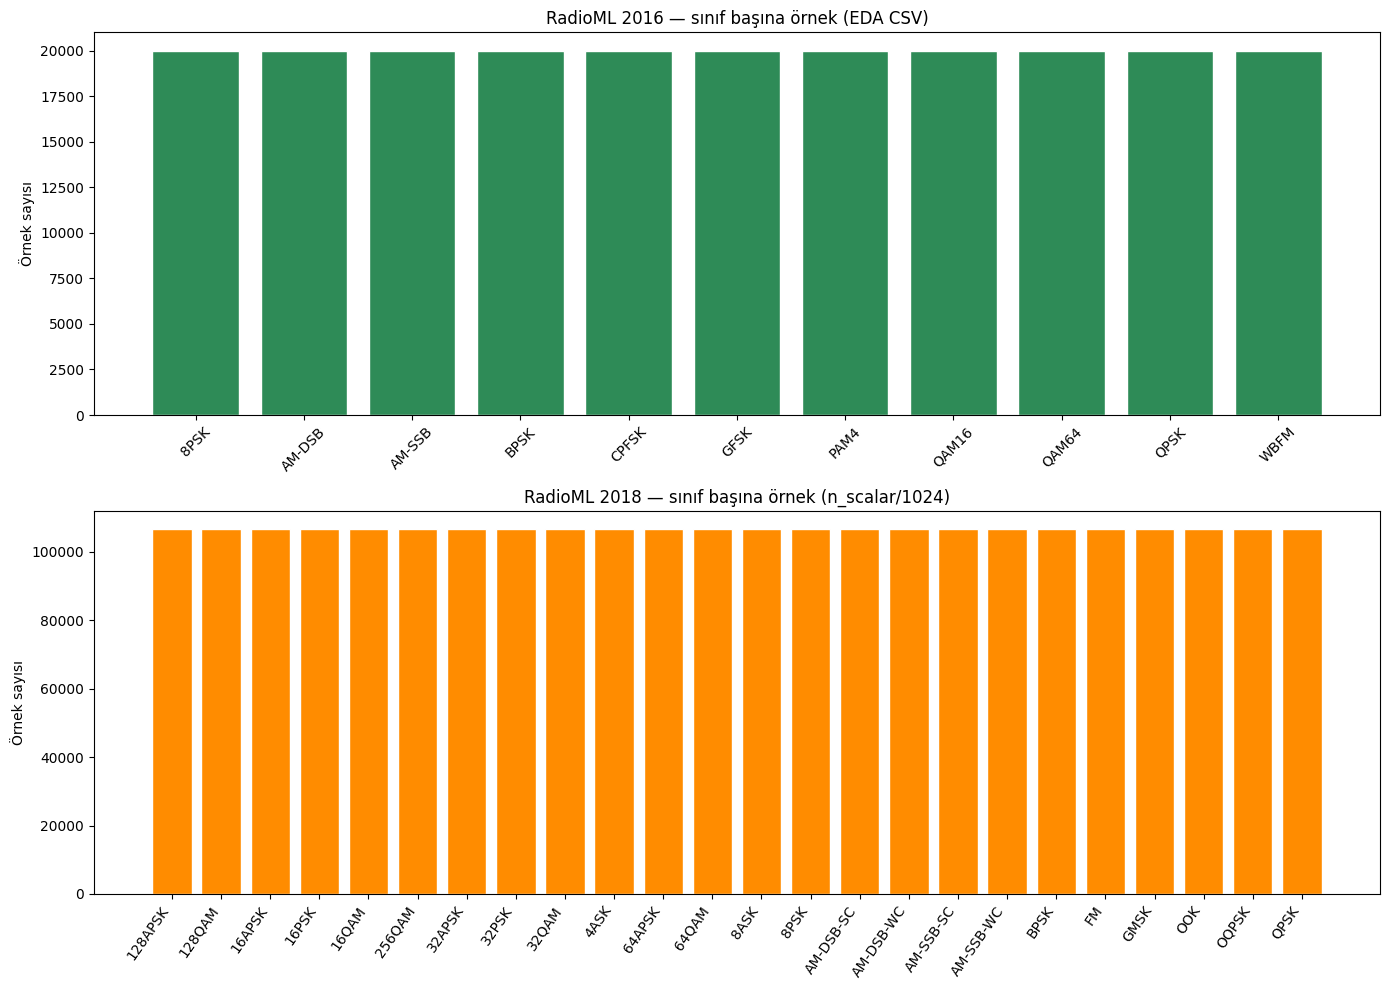

Figür: /Users/silaozyilmaz/YZG_Proje/amc-modulation-classification/results/results_compare/eda_compare_class_counts_bars.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
axes[0].bar(s16["modulation"], s16["n"], color="seagreen", edgecolor="white")
axes[0].set_title("RadioML 2016 — sınıf başına örnek (EDA CSV)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Örnek sayısı")

axes[1].bar(s18["modulation"], s18["n_rows"], color="darkorange", edgecolor="white")
axes[1].set_title("RadioML 2018 — sınıf başına örnek (n_scalar/1024)")
plt.setp(axes[1].get_xticklabels(), rotation=55, ha="right")
axes[1].set_ylabel("Örnek sayısı")
plt.tight_layout()
fig.savefig(OUT / "eda_compare_class_counts_bars.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figür:", OUT / "eda_compare_class_counts_bars.png")


## Görsel: güç–SNR eğrileri (yan yana, kaydedilmiş PNG)


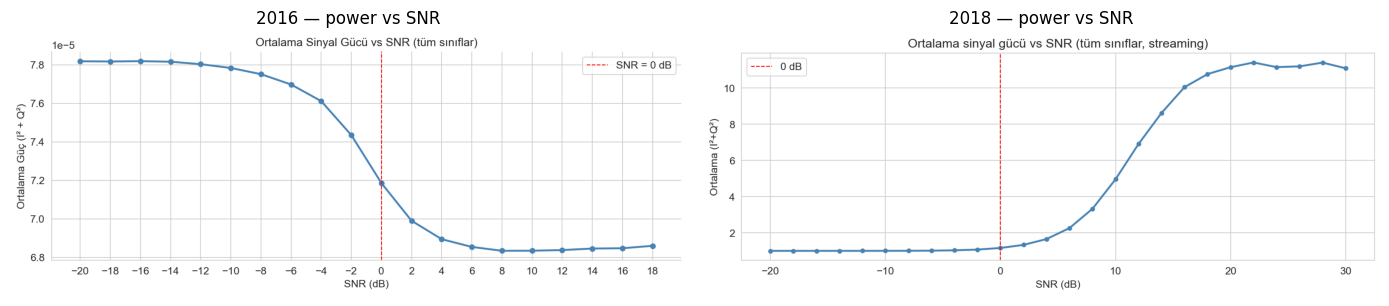

Figür: /Users/silaozyilmaz/YZG_Proje/amc-modulation-classification/results/results_compare/eda_compare_power_vs_snr_side_by_side.png


In [6]:
from matplotlib import image as mpimg

p16 = R16 / "eda_2016_power_vs_snr.png"
p18 = R18 / "eda_2018_power_vs_snr.png"
if not p16.is_file() or not p18.is_file():
    print("Eksik PNG:", p16.is_file(), p18.is_file())
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    axes[0].imshow(mpimg.imread(p16))
    axes[0].axis("off")
    axes[0].set_title("2016 — power vs SNR")
    axes[1].imshow(mpimg.imread(p18))
    axes[1].axis("off")
    axes[1].set_title("2018 — power vs SNR")
    plt.tight_layout()
    fig.savefig(OUT / "eda_compare_power_vs_snr_side_by_side.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figür:", OUT / "eda_compare_power_vs_snr_side_by_side.png")


## Öznitelik korelasyonu (aynı el yapımı vektör — CSV üzerinden)

Her iki EDA defteri aynı türetilmiş öznitelik isimlerini kullandıysa, üst üçgeni karşılaştırmak mümkün.


In [7]:
corr16 = pd.read_csv(R16 / "eda_2016_feature_correlation_matrix.csv", index_col=0)
corr18 = pd.read_csv(R18 / "eda_2018_feature_correlation_matrix.csv", index_col=0)
common = sorted(
    set(corr16.columns) & set(corr18.columns) & set(corr16.index) & set(corr18.index)
)
if len(common) < 2:
    print("Ortak sütun yetersiz")
else:
    a = corr16.loc[common, common]
    b = corr18.loc[common, common]
    diff = b - a
    print("=== Korelasyon farkı (2018 − 2016), ortak özellikler ===")
    print(diff.round(3).to_string())
    diff.to_csv(OUT / "eda_compare_feature_corr_diff.csv")
    print("\nCSV:", OUT / "eda_compare_feature_corr_diff.csv")


=== Korelasyon farkı (2018 − 2016), ortak özellikler ===
           I_mu  I_std   Q_mu  Q_std  env_mu  env_std  spec_low  zcr_I
I_mu      0.000  0.207  0.169  0.190   0.007    0.153     0.166 -0.056
I_std     0.207  0.000 -0.509 -1.354  -0.117   -0.727    -0.320 -0.009
Q_mu      0.169 -0.509  0.000 -0.531   0.005   -0.329    -0.460  0.189
Q_std     0.190 -1.354 -0.531  0.000  -0.127   -0.870    -1.108  0.253
env_mu    0.007 -0.117  0.005 -0.127   0.000    0.898     0.668 -0.860
env_std   0.153 -0.727 -0.329 -0.870   0.898    0.000     0.123 -1.360
spec_low  0.166 -0.320 -0.460 -1.108   0.668    0.123     0.000 -0.935
zcr_I    -0.056 -0.009  0.189  0.253  -0.860   -1.360    -0.935  0.000

CSV: /Users/silaozyilmaz/YZG_Proje/amc-modulation-classification/results/results_compare/eda_compare_feature_corr_diff.csv


## Adım 7 — EDA raporu taslağı (metin)

Aşağıdaki hücreyi çalıştırınca rapora yapıştırılabilir bir özet üretilir. Kendi cümlelerinizle genişletin.


In [8]:
report = f"""
---
## EDA özeti — RadioML 2016.10a ve 2018.01A

### Veri kümesi karmaşıklığı
- **2016:** {c16} modülasyon, toplam **{n16:,}** örnek; sinyal uzunluğu **128** I/Q örneği; ham dosya {file_mb(PKL_2016)}.
- **2018:** {c18} modülasyon, toplam **{n18:,}** örnek; sinyal uzunluğu **1024** I/Q örneği; ham dosya {file_mb(H5_2018)}.
- **2018** daha fazla sınıf ve daha uzun zaman penceresi içerir; etiket dengesi CSV’ye göre her iki kümede de sınıf başına örnek sayısı tutarlıdır (2016: {per16[0]} örnek/sınıf, 2018: {per18[0]} satır/sınıf).

### SNR
- **2016:** {snr_16_txt}
- **2018:** {snr_18_txt}

### Ölçek ve karşılaştırma uyarısı
2016 ve 2018 I/Q zaman serilerinin **genlik ölçekleri** farklıdır; `eda_*_stats_by_class.csv` içindeki mutlak `I_std`/`Q_std` değerlerini doğrudan kıyaslamak yanıltıcı olabilir. Karşılaştırma için dalga şekli, konstelasyon ve SNR davranışına odaklanın.

### Grafik galerisi (proje çıktıları)
| Konu | 2016 (`results_2016/`) | 2018 (`results_2018/`) |
|------|-------------------------|-------------------------|
| Dağılım | class / SNR / heatmap | class / SNR / heatmap |
| Dalga & güç | waveforms, power_vs_snr | waveforms, power_vs_snr |
| Konstelasyon | constellation_* | constellation_* |
| Öznitelik & PCA | feature_correlation*, pca_* | feature_correlation*, pca_* |

### Bu defterin ürettiği ek çıktılar (`results_compare/`)
- `eda_compare_dataset_summary.csv`, `eda_compare_modulation_pairs.csv`
- `eda_compare_class_counts_bars.png`, `eda_compare_power_vs_snr_side_by_side.png` (PNG mevcutsa)
- `eda_compare_feature_corr_diff.csv` (ortak öznitelik varsa)

---
"""
print(report)



---
## EDA özeti — RadioML 2016.10a ve 2018.01A

### Veri kümesi karmaşıklığı
- **2016:** 11 modülasyon, toplam **220,000** örnek; sinyal uzunluğu **128** I/Q örneği; ham dosya 611.2 MB.
- **2018:** 24 modülasyon, toplam **2,555,904** örnek; sinyal uzunluğu **1024** I/Q örneği; ham dosya 20455.5 MB.
- **2018** daha fazla sınıf ve daha uzun zaman penceresi içerir; etiket dengesi CSV’ye göre her iki kümede de sınıf başına örnek sayısı tutarlıdır (2016: 20000 örnek/sınıf, 2018: 106496 satır/sınıf).

### SNR
- **2016:** -20 … 18 dB (pickle anahtarları)
- **2018:** -20 … 30 dB (Z tek geçiş taraması)

### Ölçek ve karşılaştırma uyarısı
2016 ve 2018 I/Q zaman serilerinin **genlik ölçekleri** farklıdır; `eda_*_stats_by_class.csv` içindeki mutlak `I_std`/`Q_std` değerlerini doğrudan kıyaslamak yanıltıcı olabilir. Karşılaştırma için dalga şekli, konstelasyon ve SNR davranışına odaklanın.

### Grafik galerisi (proje çıktıları)
| Konu | 2016 (`results_2016/`) | 2018 (`results_2018/`) |
|------|--